# Sequential Graph


In [23]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph # framework 

In [24]:
class AgentState(TypedDict): # State schema for the agent
    name: List[str]
    age: str
    skills: List[str]
    final: str

def first_node(state: AgentState) -> AgentState:
    """First node in the sequence"""

    state['final'] = f"{state['name']}, Welcome to the system." # Initialize the final message
    return state

def second_node(state: AgentState) -> AgentState:
    """Second node in the sequence"""

    state['final'] = state['final'] + f" You are {state['age']} years old." # Continue building the final message (Concatenation)
    return state

def third_node(state: AgentState) -> AgentState:
    """Third node in the sequence"""

    state['final'] = state['final'] + " You have the following skills: " + ", ".join(state['skills']) + "."
    return state

In [25]:
graph = StateGraph(AgentState)

graph.add_node("first", first_node)
graph.add_node("second", second_node)
graph.add_node("third", third_node)

graph.set_entry_point("first") # Set the entry point of the graph to the "first" node

graph.add_edge("first", "second") # Add an edge from the "first" node to the "second" node
graph.add_edge("second", "third") # Add an edge from the "second" node to the "third" node

graph.set_finish_point("third") # Set the finish point of the graph to the "third" node

app = graph.compile() # Compile the graph into an executable application

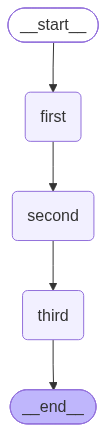

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # Display the graph image

In [28]:
result = app.invoke({"name": "Bob", "age": "25", "skills": ["Python", "JavaScript"]})  # Invoke the graph with an initial state

In [29]:
result  # Display the result of the invocation

{'name': 'Bob',
 'age': '25',
 'skills': ['Python', 'JavaScript'],
 'final': 'Bob, Welcome to the system. You are 25 years old. You have the following skills: Python, JavaScript.'}

In [30]:
result["final"]  # Display the result of the invocation

'Bob, Welcome to the system. You are 25 years old. You have the following skills: Python, JavaScript.'